In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/ANET/netflix_titles.csv"

pd = pd.read_csv(path)
pd.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
pd.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [ ]:
df = pd

In [ ]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
# Handling missing values\
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows with missing values for columns with very few nulls
df.dropna(subset=['date_added', 'rating', 'duration'], inplace=True)

# Verify cleaning\nprint('Missing values after cleaning:')
print(df.isnull().sum())
display(df.head())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
print(df['type'].value_counts())
print(df['listed_in'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64
listed_in
Dramas, International Movies                                  362
Documentaries                                                 359
Stand-Up Comedy                                               334
Comedies, Dramas, International Movies                        274
Dramas, Independent Movies, International Movies              252
                                                             ... 
Dramas, Horror Movies, Sci-Fi & Fantasy                         1
British TV Shows, TV Dramas, TV Sci-Fi & Fantasy                1
Comedies, Cult Movies, Sports Movies                            1
Action & Adventure, Faith & Spirituality, Sci-Fi & Fantasy      1
Cult Movies, Dramas, Thrillers                                  1
Name: count, Length: 513, dtype: int64


### Exploring Genres for Recommendation System

The `listed_in` column contains comma-separated genres/categories. To use this effectively for a recommendation system, we need to extract individual genres.

In [ ]:
# Extract individual genres
import numpy as np

genres = df['listed_in'].apply(lambda x: x.split(', ')).explode()
genre_counts = genres.value_counts()

print('Top 20 Genres:')
print(genre_counts.head(20))


Top 20 Genres:
listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
TV Comedies                  573
Crime TV Shows               469
Kids' TV                     448
Docuseries                   394
Music & Musicals             375
Romantic TV Shows            370
Horror Movies                357
Stand-Up Comedy              343
Reality TV                   255
Name: count, dtype: int64


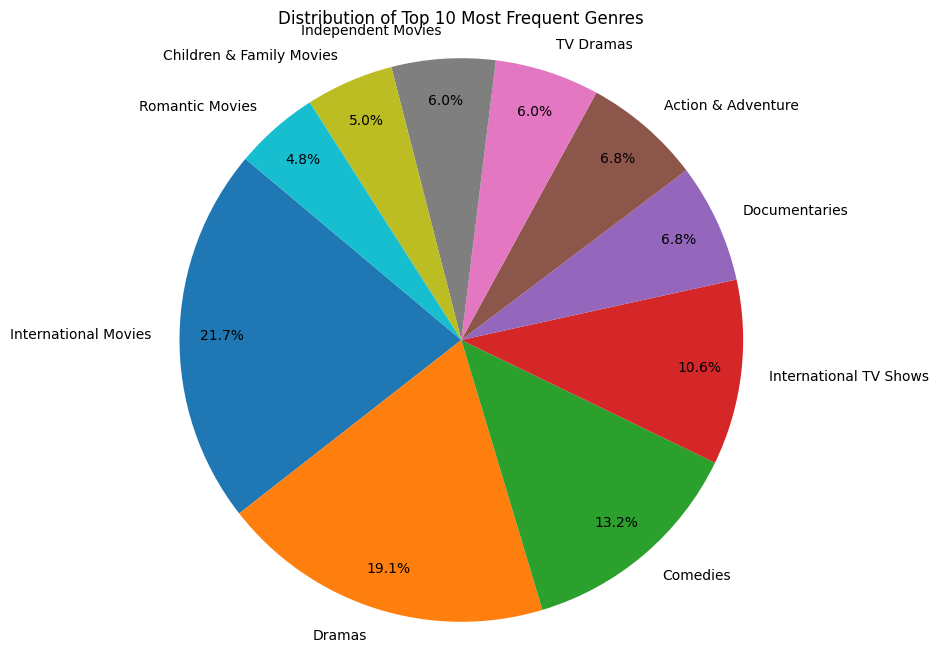

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(genre_counts.head(10).values, labels=genre_counts.head(10).index, autopct='%1.1f%%', startangle=140, pctdistance=0.85)
plt.title('Distribution of Top 10 Most Frequent Genres')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Creating a Feature Matrix for Content-Based Recommender

To build a content-based recommender, we'll create a feature matrix where each title is represented by the genres it belongs to. This is typically done using one-hot encoding.

In [ ]:
# Create a list of all unique genres
import pandas as pd

all_genres = genres.unique()

# Create a binary feature matrix
genre_feature_matrix = df['listed_in'].apply(lambda x: [1 if genre in x.split(', ') else 0 for genre in all_genres])

# Convert the list of lists into a DataFrame
genre_feature_df = pd.DataFrame(genre_feature_matrix.tolist(), columns=all_genres, index=df.index)

print('Genre Feature Matrix (first 5 rows):')
display(genre_feature_df.head())

Genre Feature Matrix (first 5 rows):


,Documentaries,International TV Shows,TV Dramas,TV Mysteries,Crime TV Shows,TV Action & Adventure,Docuseries,Reality TV,Romantic TV Shows,TV Comedies,...,Science & Nature TV,Teen TV Shows,Cult Movies,TV Shows,Faith & Spirituality,LGBTQ Movies,Stand-Up Comedy,Movies,Stand-Up Comedy & Talk Shows,Classic & Cult TV
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0


This `genre_feature_df` is our feature matrix. Each row corresponds to a Netflix title, and each column represents a genre. A '1' indicates that the title belongs to that genre, and '0' otherwise. This matrix can now be used to calculate content similarity between titles.

### Calculating Content Similarity

Now that we have our `genre_feature_df`, we can calculate the similarity between titles. Cosine similarity is a popular choice for this, as it measures the cosine of the angle between two non-zero vectors in a multi-dimensional space, effectively determining how similar the directions of these vectors are.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix
cosine_sim_matrix = cosine_similarity(genre_feature_df)

# Convert to DataFrame for better readability, using original DataFrame's index for rows and columns
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=df['title'], columns=df['title'])

print('Cosine Similarity Matrix (first 5 rows and columns):')
display(cosine_sim_df.iloc[:5, :5])

Cosine Similarity Matrix (first 5 rows and columns):


title,Dick Johnson Is Dead,Blood & Water,Ganglands,Jailbirds New Orleans,Kota Factory
title,,,,,
Dick Johnson Is Dead,1.0,0.000000,0.000000,0.0,0.000000
Blood & Water,0.0,1.000000,0.333333,0.0,0.333333
Ganglands,0.0,0.333333,1.000000,0.0,0.333333
Jailbirds New Orleans,0.0,0.000000,0.000000,1.0,0.000000
Kota Factory,0.0,0.333333,0.333333,0.0,1.000000


This `cosine_sim_df` is our similarity matrix. Each cell `(i, j)` contains the cosine similarity between title `i` and title `j`. Higher values indicate greater similarity. We can now use this matrix to recommend titles similar to a user's watched content.

### Recommendation Function

Now, let's create a function that takes a movie or TV show title and returns a list of recommended similar titles based on our cosine similarity matrix.

In [ ]:
def get_recommendations(title, cosine_sim_df, df, num_recommendations=10):
    # Get the index of the title that matches the input title
    idx = df[df['title'] == title].index[0]

    # Get the pairwise similarity scores with that title
    sim_scores = list(cosine_sim_df.iloc[idx])

    # Sort the titles based on the similarity scores
    sim_scores_sorted = sorted(enumerate(sim_scores), key=lambda x: x[1], reverse=True)

    # Get the scores of the `num_recommendations` most similar titles (excluding itself)
    sim_scores_top = sim_scores_sorted[1:num_recommendations+1]

    # Get the title indices
    movie_indices = [i[0] for i in sim_scores_top]

    # Return the top similar titles
    return df['title'].iloc[movie_indices].tolist()

### Demonstrating the Recommendation System

Let's test our recommendation function with an example title. We'll pick 'Kota Factory' to see what similar titles it recommends.

In [17]:
# Example: Get recommendations for 'Kota Factory'
recommendations = get_recommendations('Kota Factory', cosine_sim_df, df)

print(f"Recommendations for 'Kota Factory':\n")
for i, title in enumerate(recommendations):
    print(f"{i+1}. {title}")

Recommendations for 'Kota Factory':

1. The Smart Money Woman
2. Hotel Del Luna
3. Hometown Cha-Cha-Cha
4. I Need Romance
5. Office Girls
6. The Prince Who Turns into a Frog
7. Two Fathers
8. You're My Destiny
9. Feels Like Ishq
10. Her Private Life


In [20]:
recommendations = get_recommendations('Inception', cosine_sim_df, df)

print(f"Recommendations for Inception:\n")
for i, title in enumerate(recommendations):
    print(f"{i+1}. {title}")

Recommendations for Inception:

1. Paradise Hills
2. Chappie
3. Green Lantern
4. Level 16
5. Beowulf
6. Congo
7. Mortal Kombat
8. Star Trek
9. Stargate
10. The Darkest Hour


In [23]:
recommendations = get_recommendations('Mortal Kombat', cosine_sim_df, df)

print(f"Recommendations for Mortal Kombat :\n")
for i, title in enumerate(recommendations):
    print(f"{i+1}. {title}")

Recommendations for Mortal Kombat :

1. Green Lantern
2. Beowulf
3. Mortal Kombat
4. Star Trek
5. Stargate
6. The Darkest Hour
7. Battle: Los Angeles
8. Time Trap
9. 2012
10. Kingsglaive: Final Fantasy XV


### Enhancing Recommendations with Description-based Similarity

To make our recommendations more sophisticated, we can utilize the `description` column. TF-IDF (Term Frequency-Inverse Document Frequency) is a powerful technique to quantify the importance of words in a document relative to a collection of documents. By applying TF-IDF to our show descriptions, we can create a feature matrix that captures the semantic content of each title, leading to more contextually relevant recommendations.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf = TfidfVectorizer(stop_words='english', min_df=3) # min_df ignores terms that appear in too few documents

# Fit and transform the 'description' column
tfidf_matrix = tfidf.fit_transform(df['description'])

# Convert the TF-IDF matrix to a DataFrame for better inspection (optional)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out(), index=df['title'])

print('TF-IDF Matrix Shape:', tfidf_matrix.shape)
print('TF-IDF Feature Names (first 10):')
print(tfidf.get_feature_names_out()[:10])

# You can display a sample of the TF-IDF DataFrame
# display(tfidf_df.head())

TF-IDF Matrix Shape: (8790, 7105)
TF-IDF Feature Names (first 10):
['000' '007' '10' '100' '10th' '11' '12' '13' '14' '14th']


Now that we have our TF-IDF matrix for descriptions, we can calculate the cosine similarity between titles based on these descriptions. This will give us a `description_cosine_sim_df` which can be used in the same recommendation function as before.

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate the cosine similarity matrix from the TF-IDF matrix
description_cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Convert to DataFrame for better readability, using original DataFrame's title as index and columns
description_cosine_sim_df = pd.DataFrame(description_cosine_sim_matrix, index=df['title'], columns=df['title'])

print('Description-based Cosine Similarity Matrix (first 5 rows and columns):')
display(description_cosine_sim_df.iloc[:5, :5])

Description-based Cosine Similarity Matrix (first 5 rows and columns):


title,Dick Johnson Is Dead,Blood & Water,Ganglands,Jailbirds New Orleans,Kota Factory
title,,,,,
Dick Johnson Is Dead,1.000000,0.0,0.0,0.0,0.019718
Blood & Water,0.000000,1.0,0.0,0.0,0.000000
Ganglands,0.000000,0.0,1.0,0.0,0.000000
Jailbirds New Orleans,0.000000,0.0,0.0,1.0,0.000000
Kota Factory,0.019718,0.0,0.0,0.0,1.000000


Let's test the recommendation system using this new description-based similarity matrix. We'll use the same `get_recommendations` function.

In [26]:
# Example: Get recommendations for 'Kota Factory' using description similarity
recommendations_desc = get_recommendations('Kota Factory', description_cosine_sim_df, df)

print(f"Recommendations for 'Kota Factory' based on description:\n")
for i, title in enumerate(recommendations_desc):
    print(f"{i+1}. {title}")

Recommendations for 'Kota Factory' based on description:

1. The Bye Bye Man
2. Racket Boys
3. Code 8
4. Titipo Titipo
5. Train of the Dead
6. The Creative Indians
7. Crazy, Lovely, Cool
8. Cheese in the Trap
9. The Rap Game
10. The Bridge Curse


In [27]:
# Example: Get recommendations for 'Inception' using description similarity
recommendations_desc_inception = get_recommendations('Inception', description_cosine_sim_df, df)

print(f"Recommendations for 'Inception' based on description:\n")
for i, title in enumerate(recommendations_desc_inception):
    print(f"{i+1}. {title}")

Recommendations for 'Inception' based on description:

1. Dedh Ishqiya
2. Big Dreams, Small Spaces
3. Eyyvah Eyyvah 2
4. Quigley Down Under
5. Hyper HardBoiled Gourmet Report
6. Violet Evergarden
7. The Bank Job
8. Strange Weather
9. Romantik Komedi
10. Hit & Run


To better understand the TF-IDF vectorization, let's visualize the words with the highest TF-IDF scores for a specific movie's description. This highlights the most distinguishing terms for that title.

In [28]:
# Choose a movie title to visualize
movie_title = 'Inception'

# Get the index of the movie
movie_index = df[df['title'] == movie_title].index[0]

# Get the TF-IDF vector for that movie
movie_tfidf_vector = tfidf_matrix[movie_index]

# Get the feature names (words)
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame of words and their TF-IDF scores for the selected movie
tfidf_scores_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': movie_tfidf_vector.T.toarray().flatten()
})

# Sort by TF-IDF score in descending order and get the top N words
top_n_words = tfidf_scores_df.sort_values(by='tfidf_score', ascending=False).head(15)

print(f"Top TF-IDF words for '{movie_title}':")
display(top_n_words)

Top TF-IDF words for 'Inception':


,word,tfidf_score
4656,plant,0.376402
3107,idea,0.344929
6221,target,0.317407
6319,thief,0.297641
3611,leading,0.288046
6539,troubled,0.270362
1591,dangerous,0.250510
5540,secrets,0.248657
3416,job,0.243107
1957,dreams,0.242707


/tmp/ipykernel_13921/968352200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tfidf_score', y='word', data=top_n_words, palette='viridis')


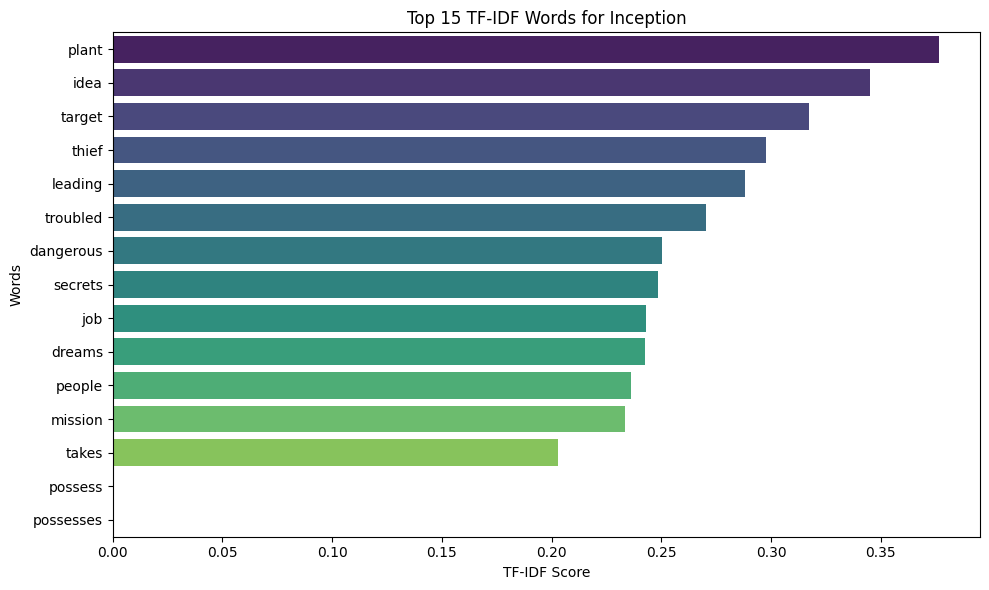

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the top TF-IDF words
plt.figure(figsize=(10, 6))
sns.barplot(x='tfidf_score', y='word', data=top_n_words, palette='viridis')
plt.title(f'Top 15 TF-IDF Words for {movie_title}')
plt.xlabel('TF-IDF Score')
plt.ylabel('Words')
plt.tight_layout()
plt.show()

In [30]:
# Choose a movie title to visualize
movie_title = 'Kota Factory'

# Get the index of the movie
movie_index = df[df['title'] == movie_title].index[0]

# Get the TF-IDF vector for that movie
movie_tfidf_vector = tfidf_matrix[movie_index]

# Get the feature names (words)
feature_names = tfidf.get_feature_names_out()

# Create a DataFrame of words and their TF-IDF scores for the selected movie
tfidf_scores_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': movie_tfidf_vector.T.toarray().flatten()
})

# Sort by TF-IDF score in descending order and get the top N words
top_n_words = tfidf_scores_df.sort_values(by='tfidf_score', ascending=False).head(15)

print(f"Top TF-IDF words for '{movie_title}':")
display(top_n_words)

Top TF-IDF words for 'Kota Factory':


,word,tfidf_score
2468,finest,0.353981
2008,earnest,0.344897
1213,coaching,0.337474
1032,centers,0.312799
940,campus,0.309256
4011,minds,0.305998
6459,train,0.261273
3539,known,0.240478
4195,navigate,0.239856
3187,india,0.219807


### Visualizing Duration Distribution with Violin Plots

To demonstrate the utility of violin plots, we can analyze the distribution of movie durations across different content ratings. First, we need to extract the numerical duration for movies from the `duration` column.

In [31]:
# Filter for movies and extract duration in minutes
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_minutes'] = movies_df['duration'].apply(lambda x: int(x.replace(' min', '')))

# Filter out TV Shows for this specific analysis
tv_shows_df = df[df['type'] == 'TV Show'].copy()
tv_shows_df['num_seasons'] = tv_shows_df['duration'].apply(lambda x: int(x.replace(' Season', '').replace('s', '')))

print("First 5 rows of Movies DataFrame with numerical duration:")
display(movies_df.head())
print("\nFirst 5 rows of TV Shows DataFrame with numerical seasons:")
display(tv_shows_df.head())

First 5 rows of Movies DataFrame with numerical duration:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127



First 5 rows of TV Shows DataFrame with numerical seasons:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,num_seasons
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1


/tmp/ipykernel_13921/115682089.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='rating', y='duration_minutes', data=movies_df, inner='quartile', palette='muted')


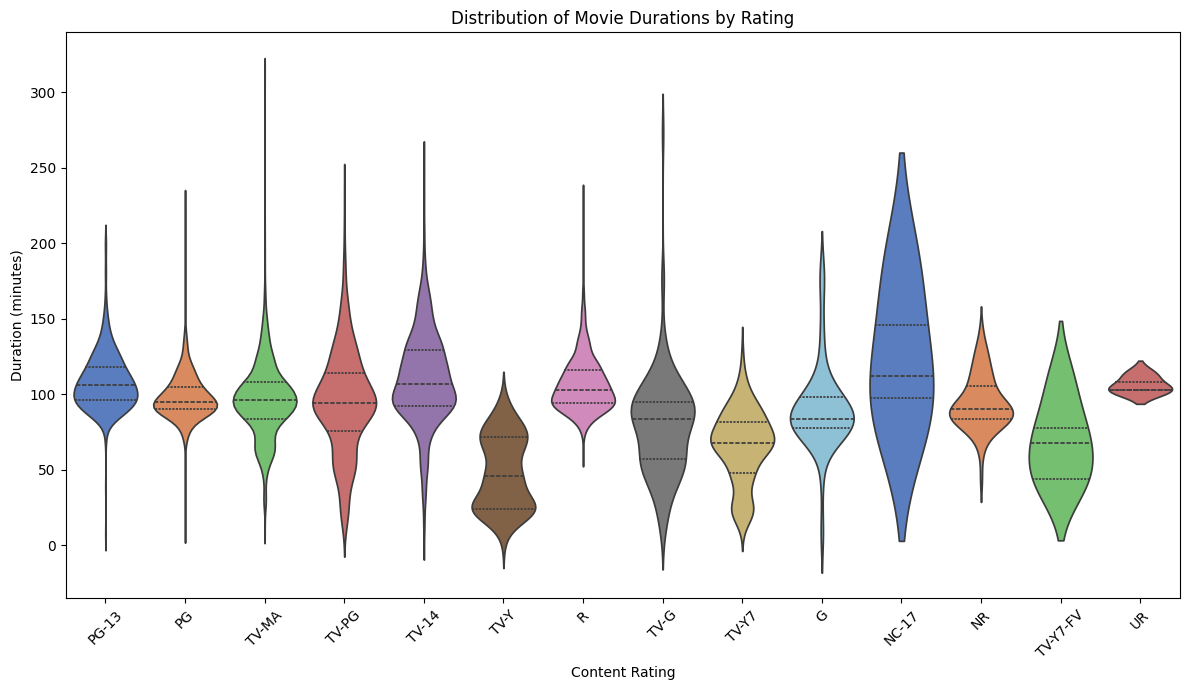

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(x='rating', y='duration_minutes', data=movies_df, inner='quartile', palette='muted')
plt.title('Distribution of Movie Durations by Rating')
plt.xlabel('Content Rating')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This violin plot shows the distribution of movie durations for each content rating. You can observe the density of durations and where the majority of movies fall, along with the median and interquartile ranges (represented by the inner box plot).